# Lab Week 9: Decision Trees, Random Forests, and Boosting

In this lab you'll train a decision tree classifier, random forest, and boosting. You'll do so on both synthetic and real data.

**Run the code cell below** to import the required packages.

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')  # headless backend
import matplotlib.pyplot as plt
import sklearn
import sklearn.tree
import sklearn.ensemble
import sklearn.datasets
import sklearn.metrics


**Run the code below** to download the data

In [ ]:
# Data files are already downloaded to the local directory
import os
data_dir = r'C:\Users\Omar Morsi\Desktop\Comp 432'
assert os.path.exists(os.path.join(data_dir, 'data_train.csv')), 'data_train.csv not found'
assert os.path.exists(os.path.join(data_dir, 'data_test.csv')), 'data_test.csv not found'
print('Data files found.')


Data files found.


<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

# 1. Fitting a Decision Tree to Synthetic Data

Exercises 1.1&ndash;1.2 ask you to apply scikit-learn's decision tree classifier (**[sklearn.tree.DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)**) to synthetic data.

**Run the code cell below** to define some useful functions for plotting data and predictions.

In [ ]:
def draw_2d_toy_data(X, y):
    """Plots a toy 2D data set. Assumes values in range [-3,3] and at most 3 classes."""
    plt.plot(X[y==0,0], X[y==0,1], 'ro', markersize=6)
    plt.plot(X[y==1,0], X[y==1,1], 'bs', markersize=6)
    plt.plot(X[y==2,0], X[y==2,1], 'gx', markersize=6, markeredgewidth=2)
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.gca().set_aspect('equal')

def draw_model_pred(model):
    """
    Plots the model's predictions over all points in range 2D [-3, 3].
    Assumes at most 3 classes.
    """
    extent = (-3, 3, -3, 3)
    x1min, x1max ,x2min, x2max = extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))
    X = np.column_stack([x1.ravel(), x2.ravel()])
    y = model.predict(X).reshape(x1.shape)
    cmap = matplotlib.colors.ListedColormap(['r', 'b', 'g'])
    plt.imshow(y, extent=extent, origin='lower', alpha=0.4, vmin=0, vmax=2, cmap=cmap, interpolation='nearest')
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.gca().set_aspect('equal')

def draw_model_class_probs(model, class_index):
    """
    Plots the model's class probability for the given class {0,1,2}
    over all points in range 2D [-3, 3]. Assumes at most 3 classes.
    """
    extent = (-3, 3, -3, 3)
    x1min, x1max ,x2min, x2max = extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))
    X = np.column_stack([x1.ravel(), x2.ravel()])
    p = model.predict_proba(X)[:,class_index].reshape(x1.shape)
    colors = [[1, 0, 0], [0, 0, 1], [0, 1, 0]]
    cmap = matplotlib.colors.ListedColormap(np.linspace([1, 1, 1], colors[class_index], 50))
    plt.imshow(p, extent=extent, origin='lower', alpha=0.4, vmin=0, vmax=1, cmap=cmap)
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.gca().set_aspect('equal')

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.1 &mdash; Train and inspect a small decision tree (2 points, 2 classes)

Read the documentation for the *DecisionTreeClassifier*'s **[fit](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.fit)** method. Notice that the $y$ vector should contain integer class labels.
You are asked to build the small 2D training set below:

$$
X = \begin{bmatrix}
-2 & 0\\
2.5 & 0
\end{bmatrix},
\quad
y = \begin{bmatrix}
0\\
1
\end{bmatrix}
$$



**Write a few lines of code** to
1. Define the training set above in two variables $X$ and $y$.
2. Train a decision tree classifier on $X$ and $y$. Use argument *random_state*=1.
3. Plot the decision tree predictions and the data (use *plot_predict* and *plot_data* from preamble).
4. Plot the decision tree itself (use **[sklearn.tree.plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)**); pass `feature_names=['x_1', 'x_2']` as an argument.

You should end up with a plot showing the data and the decision surface between classes 0 (red) and class 1 (blue). You should see a binary decision tree diagram depicting a tree of height 1 that splits the feature space using the first variable (`x_1`) at threshold ~0.2.

*Tip 1:* If you want a single code cell to generate multiple figures, call `plt.figure()` to tell Matplotlib that you want the subsequent plotting commands to generate a new, separate figure from any previous plotting commands.

*Tip 2:* If the last line of your code cell returns a value, it will be printed as the `Out` of the cell before the plots are shown. Some times you don't care about this 'final' value, for example if it is a string or some object you don't need printed. If you want to suppress the cell's `Out` value, add a semicolon (`;`) to the end of the last line of code in the cell.

In [ ]:
X = np.array([[-2, 0], [2.5, 0], [-0.5, 0], [1, 0]])
y = np.array([0, 1, 1, 0])
dt = sklearn.tree.DecisionTreeClassifier(random_state=1)
dt.fit(X, y)
plt.figure()
draw_model_pred(dt)
draw_2d_toy_data(X, y)
plt.title('Decision Tree predictions')
plt.figure()
sklearn.tree.plot_tree(dt, feature_names=['x_1', 'x_2']);


Once you have things working, **add two data points** to your training set:
* $\mathbf{x}_3 = (-\frac{1}{2}, 0)$ with class label $y_3=1$ (blue), and
* $\mathbf{x}_4 = (1, 0)$ with class label $y_4=0$ (red).

**Re-run your code cell above** and make sure you understand how the splits and thresholds you see in the tree correspond to the decision region shown.

*Note:* If a decision tree node is shown as having *value*=[1,2], it means that node's region (before splitting) contains exactly one training point from class 0 and two training points from class 1. The root note thus 'contains' the entire training set.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.2 &mdash; Train and inspect a small decision tree (3 points, 3 classes)

**Repeat Exercise 1.1** but with the following changes:
1. To the original $\mathbf{x}_1$ and $\mathbf{x}_2$, add a third training point $\mathbf{x}_3 = (0.2, -2)$ with class label $y_3=2$.
2. Print the **[feature_importances_](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_)** attribute of your trained decision tree. Intuitively, the feature importance is 0.0 if a feature is not used at all, or 1.0 if it is the only feature needed to make decisions.

This time you should see a binary decision tree of height 2, where the first split is done by thresholding the second feature (`X[1]`) and the second split is done by thresholding the first feature (`X[0]`). If a node has *value*=[1,1,0], it means that node's region (say, the red+blue region) contains exactly one training point from class 0, one training point from class 1, and zero training points from class 2.

3. Try incrementing *random_state* from 0 up to 9. How many distinct decision trees did you observe? Do the 'feature importances' make intuitive sense, given the trees that you observed?

In [ ]:
X = np.array([[-2, 0], [2.5, 0], [0.2, -2]])
y = np.array([0, 1, 2])
dt = sklearn.tree.DecisionTreeClassifier(random_state=0)
dt.fit(X, y)
print('Feature importances:', dt.feature_importances_)
plt.figure()
draw_model_pred(dt)
draw_2d_toy_data(X, y)
plt.title('Decision Tree — 3 classes')
plt.figure()
sklearn.tree.plot_tree(dt, feature_names=['x_1', 'x_2']);


Feature importances: [0.5 0.5]


<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

# 2. Fitting a Random Forest Classifier to Synthetic Data

The following exercises, ask you to apply scikit-learn's  random forest classifier (**[sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)**) to synthetic data.


<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.1 &mdash; Train and inspect a small random forest (3 points, 3  classes)

The goal of this exercise is to show you how a random forest is a collection of decision trees.

**Repeat Exercise 1.2** but this time train using a random forest classifier (**[sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)**) on the same 3-point data set. Use *random_state*=0 and *n_estimators*=3. You should see a decision region that still has axis-aligned boundaries, but different from Exercise 1.2.

In [ ]:
X = np.array([[-2, 0], [2.5, 0], [0.2, -2]])
y = np.array([0, 1, 2])
rf = sklearn.ensemble.RandomForestClassifier(n_estimators=3, random_state=0)
rf.fit(X, y)
plt.figure()
draw_model_pred(rf)
draw_2d_toy_data(X, y)
plt.title('Random Forest (n_estimators=3)')


Text(0.5, 1.0, 'Random Forest (n_estimators=3)')

A random forest builds multiple decision trees where each decision tree (each 'estimator') is trained on a different "re-samplings" of the training data. Specifically, decision tree $j$ is trained on a new training set $\mathcal{D}_j$ that is built by sampling $N$ pairs $(\mathbf{x}_i, y_i)$ from the original $N$ training examples in $\mathcal{D}$. The sampling is done "with replacement," meaning that the new training set $\mathcal{D}_j$ may contain duplicates and/or be missing some of the original data.

With the *random_state* you have chosen, the three re-samplings of $\mathcal{D}=\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), (\mathbf{x}_3, y_3) \}$ are:
* $\mathcal{D}_1 = \{(\mathbf{x}_1, y_1), (\mathbf{x}_1, y_1), (\mathbf{x}_3, y_3) \}$ (red, red, green).
* $\mathcal{D}_2 = \{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), (\mathbf{x}_2, y_2) \}$ (red, red, blue).
* $\mathcal{D}_3 = \{(\mathbf{x}_2, y_2), (\mathbf{x}_2, y_2), (\mathbf{x}_3, y_3) \}$ (blue, blue, green).

Each individual decision tree is not a good classifier.
To make a prediction, the random forest collects a prediction from each tree, and returns the class with the most "votes." The winner of these votes tends to be a good classification.

### Exercise 2.2 &mdash; Plot the decision region and decision tree
For each of the three decision trees that comprise the random forest. Read about the *estimators_* attribute in the [*RandomForestClassifier* documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). Your answer should use a for-loop *over the estimators*, generating a plot for each one. Your code should generate three figures, where each figure contains two subplots (use Matplotlib's [subplot](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.subplot.html) function). Your first pair should look like this:


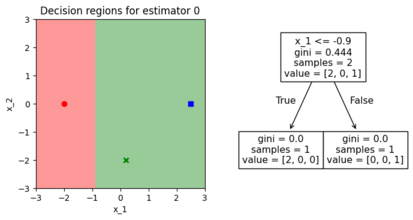

*Hint:* Remember to use `plt.figure()` to start a new figure. Pass argument `figsize=(8,4)` to the *figure* function to make a figure that's twice as wide as it is tall.

In [ ]:
for i, estimator in enumerate(rf.estimators_):
    fig = plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    draw_model_pred(estimator)
    draw_2d_toy_data(X, y)
    plt.title(f'Tree {i}: Decision regions')
    plt.subplot(1, 2, 2)
    sklearn.tree.plot_tree(estimator, feature_names=['x_1', 'x_2'])
    plt.title(f'Tree {i}: Structure')


Each of the above trees 'votes' to determine the final class for every point in input space. The next step asks you to visualize how the "votes" from these trees add up and contribute to "class probabilities."

### Exercise 2.3 &mdash; Plot the class probabilities
**Plot the class probabilities** reported by the *RandomForestClassifier* instance that you trained. Use Matplotlib's *figure*, *subplot*, and *colorbar* functions to create a single figure with three rows (one per class). For each subplot, use the *draw_model_class_probs* function (see preamble) to plot the heatmap of probablities. (This function calls *RandomForestClassifier*'s **[predict_proba](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.predict_proba)** method). Your plot should look like this, but with the probabilities filled in:



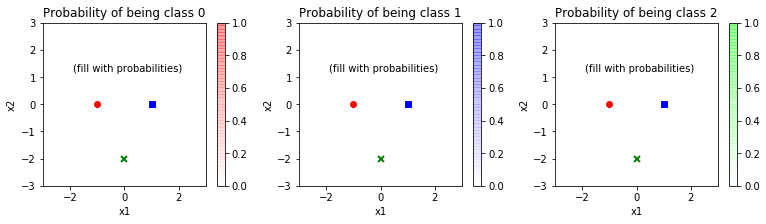

It's important not to confuse the number of trees with the number of classes, which in this case are both three.

*Tip:* As the figure you need to generate has three subplots in a row, I suggest setting *figsize=(13,3)*.

In [ ]:
fig = plt.figure(figsize=(13, 3))
for c in range(3):
    plt.subplot(1, 3, c + 1)
    draw_model_class_probs(rf, c)
    draw_2d_toy_data(X, y)
    plt.colorbar()
    plt.title(f'P(class={c})')
plt.tight_layout()


It is important to understand how the decision tree predictions lead to these probabilities. Inspect the shape of the decision regions proposed by each individual decision tree, and then ensure that you understand their correspondence with the class probabilities above.

Finally, once you understand how the three decision trees are combined, **re-run all code cells of Exercise 2.1** but use *n_estimators=10* so that there are now 10 decision trees. Notice how the final class probabilities change.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.4 &mdash; Train and inspect a small random forest on a synthetic pattern

You are asked to train a random forest classifier on a synthetic binary classification data set. Use the **[sklearn.datasets.make_circles](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html)** function to create two concentric circles.

**Write a few lines of code** to:
1. Generate the circle data, with each circle made from 11 points. Use *random_state* = 1 and factor = 0.9.
2. For each *n_estimators* in $\{1, 2, 4, 8, 16, 32, 64\}$, train a random forest (use *random_state*=0) and plot its decision regions.

You first plot should look like this:




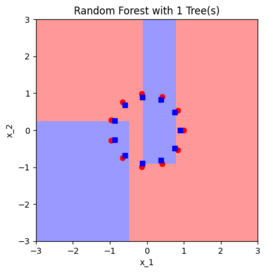

You should see a progression, where as the predictions from "more trees" are averaged together, the resulting decision regions tend to be better.

In [ ]:
X_circ, y_circ = sklearn.datasets.make_circles(n_samples=22, random_state=1, factor=0.9)
n_estimators_list = [1, 2, 4, 8, 16, 32, 64]
for n in n_estimators_list:
    rf_circ = sklearn.ensemble.RandomForestClassifier(n_estimators=n, random_state=0)
    rf_circ.fit(X_circ, y_circ)
    plt.figure()
    draw_model_pred(rf_circ)
    draw_2d_toy_data(X_circ, y_circ)
    plt.title(f'Random Forest n_estimators={n}')


### Exercise 2.5 &mdash; Plot the class probabilities

**Plot the class probabilities** of the final random forest (the one with *n_estimators*=64) using the *draw_model_class_probs* function. You should generate one figure with two subplots, each with a colour bar, similar to Exercise 2.3. Your figure should look like this (but with probabilities filled):

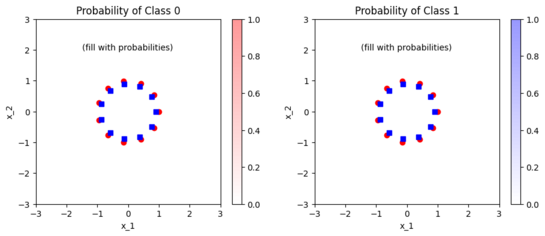

In [ ]:
fig = plt.figure(figsize=(10, 4))
for c in range(2):
    plt.subplot(1, 2, c + 1)
    draw_model_class_probs(rf_circ, c)
    draw_2d_toy_data(X_circ, y_circ)
    plt.colorbar()
    plt.title(f'P(class={c})')
plt.tight_layout()


Notice how even though the decision region is compact, the class probabilities have axis-aligned structure extending far away from the data.

Finally, **scale the second feature by a factor of two and re-run all code cells of Exercise 2.4**. You can scale the second feature by multiplying the second column in your $X$ matrix by $2$. You should see your circle vertically stretched.

After seeing all the results, make note of whether the decision regions simply scaled with the data or whether the decision regions qualitatively changed in any way.

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

# 3. Fitting a Random Forest classifier to real data

Exercises 3.1&ndash;3.5 ask you to train and evaluate decision tree and random forest classifiers across multiple hyperparameters on real data.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.1 &mdash; Load data from a CSV file and plot it

In this exercise you'll be loading the **[data_train.csv](data_train.csv)** and **[data_test.csv](data_test.csv)** files accompanying this lab. Here's a preview of the training data file:
```
sepal_length,sepal_width,label
4.9,2.4,1
4.8,3.0,0
5.1,3.3,0
7.7,3.0,2
6.2,2.8,2
...
```
This is part of the classic [Iris flower data set](https://en.wikipedia.org/wiki/Iris_flower_data_set).
The first two comman-separated columns are features. They encode characteristics of flowers. The last column is the class label, where each integer represents one of *Iris Setosa* (0), *Iris Versicolour* (1), and *Iris Virginica*.

**Write a few lines of code** to load each CSV file from disk. From the first file you should create variables *X_train* and *y_train* to refer to the training features (float64) and training labels (int32) respectively. From the second file you should likewise create variables *X_test* and *y_test*. Use the **[np.loadtxt](https://numpy.org/devdocs/reference/generated/numpy.loadtxt.html)** function to load the CSV like you did in Lab 4.

In [ ]:
import os
data_dir = r'C:\Users\Omar Morsi\Desktop\Comp 432'
data_train = np.genfromtxt(os.path.join(data_dir, 'data_train.csv'),
                           delimiter=',', skip_header=1)
data_test  = np.genfromtxt(os.path.join(data_dir, 'data_test.csv'),
                           delimiter=',', skip_header=1)
inputs_train = data_train[:, :2].astype(np.float64)
labels_train = data_train[:, 2].astype(np.int32)
inputs_test  = data_test[:, :2].astype(np.float64)
labels_test  = data_test[:, 2].astype(np.int32)
print('Train:', inputs_train.shape, labels_train.shape)
print('Test: ', inputs_test.shape, labels_test.shape)


Train: (80, 2) (80,)
Test:  (70, 2) (70,)


**Check your answer** by running the code cell below.

In [ ]:
assert 'inputs_train' in globals(), "No inputs_train variable!"
assert 'labels_train' in globals(), "No labels_train variable!"
assert 'inputs_test' in globals(), "No inputs_test variable!"
assert 'labels_test' in globals(), "No labels_test variable!"
assert isinstance(inputs_train, np.ndarray)
assert isinstance(labels_train, np.ndarray)
assert isinstance(inputs_test, np.ndarray)
assert isinstance(labels_test, np.ndarray)
assert inputs_train.shape == (80,2), "inputs_train was wrong shape!"
assert inputs_train.dtype in (np.float32, np.float64), "inputs_train was wrong data type!"
assert labels_train.shape == (80,), "labels_train was wrong shape!"
assert labels_train.dtype == np.int32, "labels_train was wrong data type!"
assert inputs_test.shape == (70,2), "inputs_test was wrong shape!"
assert inputs_test.dtype in (np.float32, np.float64), "inputs_test was wrong data type!"
assert labels_test.shape == (70,), "labels_test was wrong shape!"
assert labels_test.dtype == np.int32, "labels_test was wrong data type!"
print("Correct!")

Correct!


**Plot the training and testing data** by completing the plotting code below, much like you did in Exercise 2.1 of Lab 4. When you run the code cell it will generate two figures, and the first one should look like this:


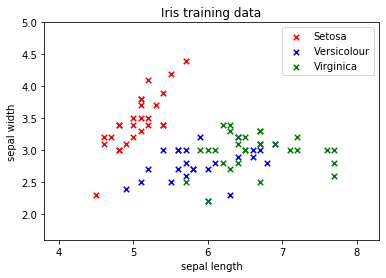

In [ ]:
iris_extent = (3.8, 8.3, 1.6, 5)   # (x1min, x1max, x2min, x2max)

def draw_real_iris_data(X, y, title):
    x1min, x1max, x2min, x2max = iris_extent
    plt.scatter(X[y==0, 0], X[y==0, 1], c='r', marker='o', label='class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='b', marker='s', label='class 1')
    plt.scatter(X[y==2, 0], X[y==2, 1], c='g', marker='x', label='class 2', linewidths=2)
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.xlabel('sepal_length')
    plt.ylabel('sepal_width')
    plt.legend()
    plt.title(title)

plt.figure()
draw_real_iris_data(inputs_train, labels_train, 'Iris Training Data')

plt.figure()
draw_real_iris_data(inputs_test, labels_test, 'Iris Test Data')


<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.2 &mdash; Train a decision tree on the Iris data and plot it

You must train a decision tree on the Iris training data, and plot the decision regions. Your final result should look like this:


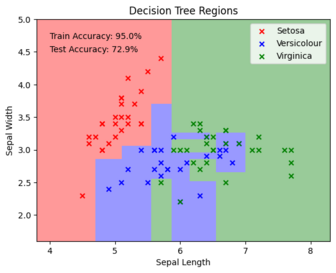


**Write a few lines of code** to:
1. Train a *DecisionTreeClassifier* object on the training data.
2. Plot the resulting predictor. Use *random_state*=0.
3. Add text to your plot showing the accuracy of the classifier when predicting on the training data and when predicting on the held-out test data. Use the **[sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score)** function and Matplotlib's **[text](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.text.html)** function.

For plotting, you cannot use the *plot_predict* function from Exercise 1 because it assumes extents (-3, 3, -3, 3), but you can adapt that code to work for the range of Iris data below.

*Tip:* When you are formatting a string like `"%.1f" % accuracy` and you want to add a `%` symbol to the string, use two `%%` symbols in a row as in `"%.1f%%" % accuracy`. This lets Python know not to expect a second value to substitute into the string, and to just print `%` in that spot.

In [ ]:
def draw_iris_prediction(model):
    x1min, x1max, x2min, x2max = iris_extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100),
                          np.linspace(x2min, x2max, 100))
    X_grid = np.column_stack([x1.ravel(), x2.ravel()])
    y_pred = model.predict(X_grid).reshape(x1.shape)
    cmap = matplotlib.colors.ListedColormap(['r', 'b', 'g'])
    plt.imshow(y_pred, extent=[x1min, x1max, x2min, x2max], origin='lower',
               alpha=0.4, vmin=0, vmax=2, cmap=cmap, interpolation='nearest', aspect='auto')
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])

dt = sklearn.tree.DecisionTreeClassifier(random_state=1)
dt.fit(inputs_train, labels_train)
train_acc = sklearn.metrics.accuracy_score(labels_train, dt.predict(inputs_train))
test_acc  = sklearn.metrics.accuracy_score(labels_test, dt.predict(inputs_test))
print(f'Training accuracy: {train_acc:.3f}')
print(f'Test accuracy:     {test_acc:.3f}')
plt.figure()
draw_iris_prediction(dt)
draw_real_iris_data(inputs_train, labels_train,
                    f'Decision Tree (train={train_acc:.2f}, test={test_acc:.2f})')


Training accuracy: 0.950
Test accuracy:     0.729


**Plot the decision tree** using the *plot_tree* function. You'll need to use the *figure* function with *figsize*=(16,16) in order to make the figure large enough to see all the details. Remember the hint about ending a line with a semicolon (`;`).


In [ ]:
plt.figure(figsize=(16, 16))
sklearn.tree.plot_tree(dt, feature_names=['sepal_length', 'sepal_width']);


C:\Users\Omar Morsi\AppData\Local\Temp\ipykernel_6392\3199998787.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(16, 16))


<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.3 &mdash; Train decision trees of different depths

You are asked to train multiple decision trees, each with a different *max_depth* parameter, and plot the resulting decision regions and training/test accuracy. The maximum depth of a decision tree controls how finely the tree is allowed to split the feature space before it must predict a class label. A depth of 1 means it is only allowed one split. Your first figure should look like this:


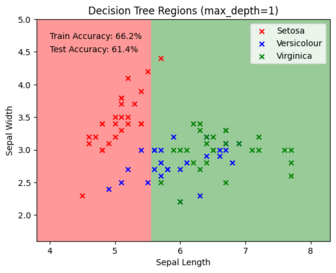



**Write a few lines of code** to create nine figures: one for each value of *max_depth* $\in \{1, \ldots, 9\}$. Use a for-loop in your answer. On each iteration, train a new classifier using *random_state*=1. Use the *plot_iris_data* and your *plot_iris_predict* functions.

In [ ]:
for max_depth in range(1, 10):
    dt_d = sklearn.tree.DecisionTreeClassifier(max_depth=max_depth, random_state=1)
    dt_d.fit(inputs_train, labels_train)
    tr = sklearn.metrics.accuracy_score(labels_train, dt_d.predict(inputs_train))
    te = sklearn.metrics.accuracy_score(labels_test,  dt_d.predict(inputs_test))
    print(f'max_depth={max_depth}: train={tr:.3f}  test={te:.3f}')
    plt.figure()
    draw_iris_prediction(dt_d)
    draw_real_iris_data(inputs_train, labels_train,
                        f'DT max_depth={max_depth} (train={tr:.2f}, test={te:.2f})')


max_depth=1: train=0.662  test=0.614
max_depth=2: train=0.787  test=0.714
max_depth=3: train=0.812  test=0.700
max_depth=4: train=0.838  test=0.729
max_depth=5: train=0.875  test=0.686
max_depth=6: train=0.900  test=0.700
max_depth=7: train=0.912  test=0.714
max_depth=8: train=0.938  test=0.729
max_depth=9: train=0.950  test=0.729


What happens to the training accuracy as *max_depth* increases? What is the maximum test accuracy of a decision tree classifier on this data set?

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.4 &mdash; Train random forests of different depths

**Repeat Exercise 3.3** but this time train a *RandomForestClassifier* instead of a *DecisionTreeClassifier*. Use *random_state*=1 and *n_estimators*=100.

In [ ]:
for max_depth in range(1, 9):
    rf_d = sklearn.ensemble.RandomForestClassifier(
        max_depth=max_depth, n_estimators=100, random_state=1)
    rf_d.fit(inputs_train, labels_train)
    tr = sklearn.metrics.accuracy_score(labels_train, rf_d.predict(inputs_train))
    te = sklearn.metrics.accuracy_score(labels_test,  rf_d.predict(inputs_test))
    print(f'max_depth={max_depth}: train={tr:.3f}  test={te:.3f}')
    plt.figure()
    draw_iris_prediction(rf_d)
    draw_real_iris_data(inputs_train, labels_train,
                        f'RF max_depth={max_depth} (train={tr:.2f}, test={te:.2f})')


max_depth=1: train=0.750  test=0.671

max_depth=2: train=0.812  test=0.771
max_depth=3: train=0.850  test=0.771


max_depth=4: train=0.887  test=0.786


max_depth=5: train=0.912  test=0.786
max_depth=6: train=0.950  test=0.771


max_depth=7: train=0.950  test=0.757


max_depth=8: train=0.950  test=0.757


What happens to the training accuracy as *max_depth* increases? What is the maximum test accuracy of a random forest classifier on this data set?

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.5 &mdash; Evaluate training and test accuracy across two hyperparameters

The performance of *RandomForestClassifier* depends on many hyperparameters. Here you'll perform a sweep over *max_depth* (as you did in Exercise 3.3) and also *n_estimators* (as you did in Exercise 2.4). Instead of plotting the decisions in input space, you'll plot a heatmap of the accuracy for each parameter setting.

You must evaluate the training and test accuracy of *RandomForestClassifier* for every combination of
* *max_depth* $\in \{1, 2, 3, 4, 5, 6, 7, 8, 9\}$
* *n_estimators* $ \in \{1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024\}$

The results should be compiled into a two-dimensional ndarray and plotted as a heatmap with properly labeled axes. Your training accuracy plot should look like this:


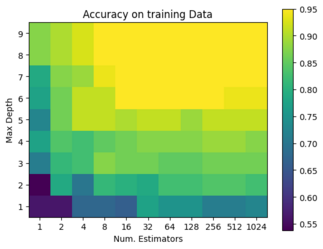

**Write code** to evaluate the training and testing accuracy for all the above combinations. Since training many models may take a few seconds, the plotting should be done in a subsequent code cell, without having to re-run the experiment.

*Tip:* If you build a $9 \times 11$ array of accuracies and plot them using Matplotlib's *imshow* function, Matplotlib does not know which values of *max_depth* each row $0,\ldots,8$ corresponds to, nor does it know which value of *n_estimators* each column $0,\ldots,10$ corresponds to. You can specify the values to use via the **[xticks](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xticks.html)** function, where for example `plt.xticks([0,1,2], [10,20,40])` would cause Matplotlib to display labels *10, 20, 40* at the $x$-axis positions, instead of its default "guess" of displaying *0, 1, 2*.

In [ ]:
max_depths        = list(range(1, 10))                       # 9 values
n_estimators_list = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]  # 11 values

train_accs = np.zeros((len(max_depths), len(n_estimators_list)))
test_accs  = np.zeros((len(max_depths), len(n_estimators_list)))

for i, md in enumerate(max_depths):
    for j, ne in enumerate(n_estimators_list):
        rf_ij = sklearn.ensemble.RandomForestClassifier(
            max_depth=md, n_estimators=ne, random_state=1)
        rf_ij.fit(inputs_train, labels_train)
        train_accs[i, j] = sklearn.metrics.accuracy_score(
            labels_train, rf_ij.predict(inputs_train))
        test_accs[i, j]  = sklearn.metrics.accuracy_score(
            labels_test, rf_ij.predict(inputs_test))

print('Done. train_accs shape:', train_accs.shape)


Done. train_accs shape: (9, 11)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, accs, title in zip(axes,
                            [train_accs, test_accs],
                            ['Training Accuracy', 'Test Accuracy']):
    plt.sca(ax)
    plt.imshow(accs, aspect='auto', vmin=0, vmax=1, origin='upper')
    plt.colorbar()
    plt.xticks(range(len(n_estimators_list)), n_estimators_list, rotation=45)
    plt.yticks(range(len(max_depths)), max_depths)
    plt.xlabel('n_estimators')
    plt.ylabel('max_depth')
    plt.title(title)

plt.tight_layout()


For what combination(s) of (*max_depth*, *n_estimators*) does the random forest classifier have highest accuracy **on the test data**? Is the accuracy trend on the test data different than the trend on the training data?

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

# 4. Understanding how AdaBoost makes predictions

The goal of this excercise is to get a sense for how a several estimators can be summed together to make a strong predictor. In a random forest, each estimator is trained independently before averaging. In boosting, the estimators are trained sequentially, with each new estimator asked to "correct" mistakes made by the collection of previous estimators.

You will see that each estimator is a very simple decision tree, also called a "decision stump" because it only has one split (*max_depth=1*). The use of shallow trees is deliberate: their shallowness makes them individually 'weak' at predicting, but easier to combine (to "boost") into a strong predictor.


Exercises 4.1&ndash;4.2 ask you to train scikit-learn's AdaBoost classifier (**[sklearn.ensemble.AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)**) and to inspect the way it makes predictions.

**Run the code cell below** to define some useful functions for plotting data and predictions.

In [ ]:
def draw_2d_toy_data(X, y):
    """Plots a toy 2D data set. Assumes values in range [-3,3] and at most 3 classes."""
    plt.plot(X[y==0,0], X[y==0,1], 'ro', markersize=6)
    plt.plot(X[y==1,0], X[y==1,1], 'bs', markersize=6)
    plt.plot(X[y==2,0], X[y==2,1], 'gx', markersize=6, markeredgewidth=2)
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.gca().set_aspect('equal')

def draw_model_pred(model):
    """
    Plots the model's predictions over all points in range 2D [-3, 3].
    If argument is already a Numpy array, treats it as predictions.
    Otherwise calls the argument's predict() function to generate predictions.
    Assumes at most 3 classes.
    """
    extent = (-3, 3, -3, 3)
    x1min, x1max ,x2min, x2max = extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))
    X = np.column_stack([x1.ravel(), x2.ravel()])
    y = model.predict(X).reshape(x1.shape)
    cmap = matplotlib.colors.ListedColormap(['r', 'b', 'g'])
    plt.imshow(y, extent=extent, origin='lower', alpha=0.4, vmin=0, vmax=2, cmap=cmap, interpolation='nearest')
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.gca().set_aspect('equal')

def draw_model_class_probs(model, class_index):
    """
    Plots the model's class probability for the given class {0,1,2}
    over all points in range 2D [-3, 3]. Assumes at most 3 classes.
    """
    extent = (-3, 3, -3, 3)
    x1min, x1max ,x2min, x2max = extent
    x1, x2 = np.meshgrid(np.linspace(x1min, x1max, 100), np.linspace(x2min, x2max, 100))
    X = np.column_stack([x1.ravel(), x2.ravel()])
    p = model.predict_proba(X)[:,class_index].reshape(x1.shape)
    colors = [[1, 0, 0], [0, 0, 1], [0, 1, 0]]
    cmap = matplotlib.colors.ListedColormap(np.linspace([1, 1, 1], colors[class_index], 50))
    plt.imshow(p, extent=extent, origin='lower', alpha=0.4, vmin=0, vmax=1, cmap=cmap, interpolation='nearest')
    plt.xlim([x1min, x1max])
    plt.ylim([x2min, x2max])
    plt.gca().set_aspect('equal')

<div style="border-bottom: 3px solid black;"></div>

### Exercise 4.1 &mdash; Compare an AdaBoost classifier to a simple decision tree

The goal of this exercise is to show you that with multiple shallow "decision stumps" we can still produce the same output as single deep decision tree. Start by training a decision tree classifier like you did in Lab5. (No boosting yet.)

**Step 1: Train a decision tree classifier like you did in the previous lab.**

**Write a few lines of code** to:

1. Build the small 2D training set below:

$$
X = \begin{bmatrix}
-\frac{3}{2} & 0\\
-\frac{1}{3} & 0\\
\frac{1}{2} & 0\\
\frac{3}{2} & 0
\end{bmatrix},
\quad
y = \begin{bmatrix}
1\\
0\\
1\\
0
\end{bmatrix}
$$

2. Train a decision tree classifier on $X$ and $y$. Use argument *random_state*=0.
3. Plot the decision tree predictions and the data (use *plot_predict* and *plot_data* from preamble).
4. Plot the decision tree in a second figure (use **[sklearn.tree.plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)**); pass `feature_names=['x_1', 'x_2']` as an argument.

In [ ]:
X_1d = np.array([[-3/2, 0], [-1/3, 0], [1/2, 0], [3/2, 0]])
y_1d = np.array([1, 0, 1, 0])
dt_1d = sklearn.tree.DecisionTreeClassifier(random_state=0)
dt_1d.fit(X_1d, y_1d)
plt.figure()
draw_model_pred(dt_1d)
draw_2d_toy_data(X_1d, y_1d)
plt.title('Decision Tree on 1D data')
plt.figure(figsize=(8, 4))
sklearn.tree.plot_tree(dt_1d, feature_names=['x_1', 'x_2']);


Having already completed the previous lab, you should understand exactly what you see above, i.e., how the decision tree thresholds, and the leaves, determine the red/blue regions plotted in feature space. You know from lecture that the training accuracy of a decision tree classifier is improved by "splitting" a leaf.

**Step 2: Train an *AdaBoostClassifier* on the same data.**

AdaBoost does not try to improve training accuracy by adding complexity to the current tree. In fact, each tree that AdaBoost builds only has one split (*max_depth*=1), so it is hardly a tree at all. Such a 'weak' tree is often called a "decision stump" instead of "decision tree."

Here you will train an AdaBoost classifier and see how it combines these 'stumps' to give a result comparable to the decision tree you trained. The decision stumps of an AdaBoostClassifier object are available via the *estimators_* attribute, which is a list of *DecisionTreeClassifier* objects.


**Write a few lines of code** to:
1. Train an **[AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)** on the same data set. Use *n_estimators*=3 as an argument when building your classifier in order to keep it simple enough to inspect closely. Specify *algorithm*='SAMME' to use a more classical variant of AdaBoost that more closely aligns with what you will learn in class. Use *random_state*=0 for reproducibility.
2. Plot the decision regions and data like you did for the decision tree.
3. Plot the tree structure of each decision stump in a separate figure. Use *sklearn.tree.plot_tree*.

In [ ]:
ada = sklearn.ensemble.AdaBoostClassifier(n_estimators=3, random_state=0)
ada.fit(X_1d, y_1d)
plt.figure()
draw_model_pred(ada)
draw_2d_toy_data(X_1d, y_1d)
plt.title('AdaBoost (n_estimators=3)')


Text(0.5, 1.0, 'AdaBoost (n_estimators=3)')

Now you have now trained an AdaBoost classifier and should see that it generates the same predictions as your original decision tree.

**Step 3: Plot the individual decision stumps of your boosted ensemble**

Finally, you should inspect the individual decision 'stumps' that AdaBoost is using to generate its predictions. You should generate three figures (one for each stump, of which there are *n_estimators*). Each figure should have two subplots: on the left plot decision regions of the stump along with the training data, and on the right plot the split that the stump uses to predict class labels. Your first figure should like this:



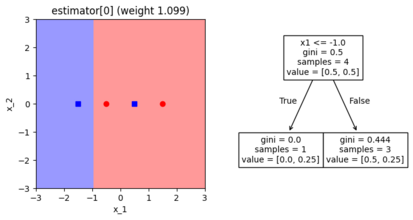

Each decision stump (each estimator) has a weight associated with it. This is the weight the model is given when making predictions. Find the weight using the *estimator_weights_* attribute of the AdaBoostClassifier and include the weight as part of the title, as shown above.

**Write plotting code** below. There should be one plot per estimator in your trained *AdaBoostClassifier* object. The i<sup>th</sup> plot should have two subplots side-by-side: (1) the decision regions of the i<sup>th</sup> estimator, and (2) the decision tree (stump) for the i<sup>th</sup> estimator.

In [ ]:
for i, (estimator, weight) in enumerate(
        zip(ada.estimators_, ada.estimator_weights_)):
    fig = plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    draw_model_pred(estimator)
    draw_2d_toy_data(X_1d, y_1d)
    plt.title(f'Stump {i}  weight={weight:.3f}')
    plt.subplot(1, 2, 2)
    sklearn.tree.plot_tree(estimator, feature_names=['x_1', 'x_2'])
    plt.title(f'Tree {i}')


The AdaBoost training procedure that led to these particular stumps has been made clear in lecture. The rough idea behind AdaBoost training is that the $R^\text{th}$ decision stump is trained to fix the mistakes (misclassifications) that the previous decision stumps $1,\ldots,R-1$ are currently making on the training set. As long as this new decision stump can fix at least one mistake, we can continue "boosting" by adding more.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 4.2 &mdash; Compute an AdaBoost prediction "by hand"

The point of Exercise 4.1 was to show that complex decision regions can be built not just by deepening a decision tree, but also by (somehow) combining the predictions of decision stumps.

Here you will learn precisely how that 'combining' happens. You will reproduce AdaBoost's predictions by writing your own code to combine the decision stump predictions.

**Run the code cell below** to define a function that will plot the training data along the $x$-axis only, using just component $x_{i1}$ of each training point $\mathbf{x}_i = (x_{i1}, x_{i2})$. For this exercise your plots will use the $y$-axis to represent the probability of class 1 (blue).

In [ ]:
def draw_1d_data(X, y):
    """
    Plots just the first component of a toy 2D data set.
    Assumes values in range [-3,3] and at most 3 classes.
    """
    plt.plot([-3, 3], [0.5, 0.5], '--k', alpha=0.25)
    plt.plot(X[y==0,0], X[y==0,1]*0+0.5, 'ro', markersize=6)
    plt.plot(X[y==1,0], X[y==1,1]*0+0.5, 'bs', markersize=6)
    plt.plot(X[y==2,0], X[y==2,1]*0+0.5, 'gx', markersize=6, markeredgewidth=2)
    plt.xlim([-3, 3])
    plt.xlabel('x1')

**Step 1: Plot the prediction of each decision stump, separately.**

Before combining the decision stumps, plot the predictions of each stump as a 1-dimensional function, so that it will be easier to see how they add up.

Specifically, plot each decision stump's class prediction along the $x_1$ dimension, using the $y$-axis to show the class probability. You should generate three figures, one for each decision stump (each estimator). Your first figure should look like:


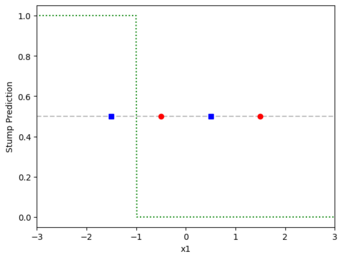

Note that the green line here is not a decision boundary! We are plotting a 1-dimensional feature space, so the place where the green line crosses the $y$-axis at 0.5 is the decision boundary! The above plot corresponds to the decision region of the first decision stump you plotted in Exercise 1.1, i.e., red region to the left, blue region to the right.

**Write plotting code** to show the separate class prediction of each stump.
* Use *draw_1d_data* to plot the four training points.
* For plotting, build an array of the $x$-axis values. Specifically, use the [np.linspace](https://numpy.org/devdocs/reference/generated/numpy.linspace.html) function to create an array of $N=500$ equally-spaced $x$ values in range $[-4, 4]$.
* To generate $y$-axis values for your plot, you'll need to call the *predict* function on your already-trained *AdaBoostClassifier* object (from previous exercise). You should generate all $N$ values using a single call to predict. To do this, build an $(N,2)$ matrix $\mathbf{X}$, where the first column ($x_1$) is filled with $x$-axis values and the second column ($x_2$) is filled with zeros. Then call *predict* once.
* Once you have a single plot working, use a for-loop to generate a separate figure for each decision stump. Use the *n_estimators* attribute of your trained *AdaBoostClassifier*, rather than hard-coding 3 iterations.

In [ ]:
x_line = np.linspace(-4, 4, 500)
X_line = np.column_stack([x_line, np.zeros(500)])

for i in range(ada.n_estimators):
    probs = ada.estimators_[i].predict_proba(X_line)[:, 1]
    plt.figure()
    plt.plot(x_line, probs, 'g-', linewidth=2)
    draw_1d_data(X_1d, y_1d)
    plt.ylabel('P(class=1)')
    plt.ylim([-0.1, 1.1])
    plt.title(f'Stump {i}  (weight={ada.estimator_weights_[i]:.3f})')


You should see that the class predictions correspond with the red/blue decision regions for each stump that you observed at the end of Exercise 4.1.

**Step 2: Plot a weighted combination of the decision stump predictions.**

Here you will plot a *weighted combination* of the individual decision stump predictions. Given an input $\mathbf{x}$, an AdaBoost classifier's decision function $y(\mathbf{x})$ is computed as a weighted combination of decision strump class predictions. Let $f_r(\mathbf{x})$ denote the $r^\text{th}$ decision stump, and $w_r$ be its weight. A prediction is then:

$$
y(\mathbf{x}) = \frac{\sum_{r=1}^R w_r f_r(\mathbf{x})}{\sum_{r=1}^R w_r}
$$


This exercise asks you to implement the above function manually, in Numpy. In effect, you'll implement the "prediction" part of a trained AdaBoost classifier. Since the training data only varies in the first feature ($x_1$), you'll plot it over the range $x_1 \in [-3,3]$ and $x_2=0$ just like you did in the previous step.

For example, if you made an AdaBoost classifier with $R=2$ decision stumps, your plot might look something like this:



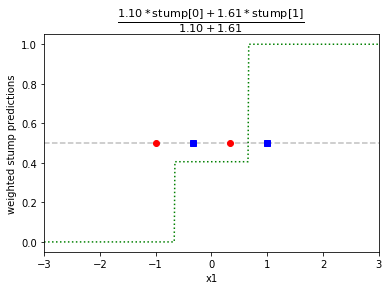

**Write code** to
* Compute the AdaBoost decision function formula $y(\mathbf{x})$ directly from the *estimators_* and *estimator_weights_* attributes of your already-trained AdaBoostClassifier object. You will be plotting the predictions over $x_1 \in [-4, 4]$, so you can just pass your matrix $\mathbf{X}$ from the previous step.
* Plot the $y(\mathbf{x})$ predictions.
* Plot the training data as before (*plot_1d_data*)

In [ ]:
x_line = np.linspace(-4, 4, 500)
X_line = np.column_stack([x_line, np.zeros(500)])

# y(x) = sum_r(w_r * f_r(x)) / sum_r(w_r)
y_manual = np.zeros(500)
for estimator, weight in zip(ada.estimators_, ada.estimator_weights_):
    y_manual += weight * estimator.predict(X_line)
y_manual /= ada.estimator_weights_.sum()

plt.figure()
plt.plot(x_line, y_manual, 'b-', linewidth=2)
draw_1d_data(X_1d, y_1d)
plt.ylabel('y(x)')
plt.ylim([-0.1, 1.1])
plt.title('AdaBoost manual weighted combination')


Text(0.5, 1.0, 'AdaBoost manual weighted combination')

Finally, compare your plot above to the result of calling *decision_function* on your trained *AdaBoostClassifier* object. However, the scikit-learn *AdaBoostClassifier* implementation treats binary classification as special: it generates class predictions in range $[-1, 1]$ rather than in range $[0, 1]$. So, to get the exact same results, you may have to scale (by factor of $\frac{1}{2}$) and shift (by $+\frac{1}{4}$) the *AdaBoostClassifier*'s decision function.

**Write a few lines of code** to call *decision_function* to generate predictions over the range $x_1 \in [-4, 4]$ just as you did already. (You can re-use variables that you already defined from earlier code cells.) The plot you generate using scikit-learn should be identical to the one you generated by hand, and it should correctly classify all red and blue points in the training set.

In [ ]:
x_line = np.linspace(-4, 4, 500)
X_line = np.column_stack([x_line, np.zeros(500)])

# sklearn SAMME decision_function is in [-1,1]; scale+shift to match y(x)
y_sklearn = ada.decision_function(X_line) * 0.5 + 0.25

plt.figure()
plt.plot(x_line, y_sklearn, 'r-', linewidth=2)
draw_1d_data(X_1d, y_1d)
plt.ylabel('y(x)')
plt.ylim([-0.1, 1.1])
plt.title('AdaBoost sklearn decision_function (scaled+shifted)')


Text(0.5, 1.0, 'AdaBoost sklearn decision_function (scaled+shifted)')

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

### Exercise 4.3 &mdash; Create a classification dataset using scikit-learn

Exercises 4.1&ndash;4.2 ask you to train and inspect an AdaBoost classifier on a real data set, to see how each successive 'weak' classifier increases the overall training accuracy when weighted with the previous weak classifiers.

<div style="border-bottom: 3px solid black;"></div>



Here you'll create a synthetic dataset using one of scikit-learn's dataset utilities. Use the **[sklearn.datasets.make_gaussian_quantiles](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_gaussian_quantiles.html)** function to generate a 2-dimensional synthetic dataset with three classes (the default).

**Write a few lines of code** to generate the dataset and plot it. Use *random_state*=0. Your plot should look exactly like this:

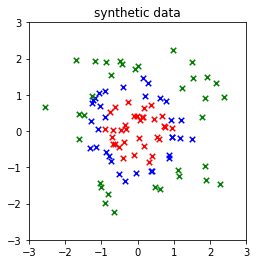

In [ ]:
X_gauss, y_gauss = sklearn.datasets.make_gaussian_quantiles(
    n_classes=3, n_samples=200, random_state=0)
plt.figure()
draw_2d_toy_data(X_gauss, y_gauss)
plt.title('Gaussian Quantiles Dataset (3 classes)')


Text(0.5, 1.0, 'Gaussian Quantiles Dataset (3 classes)')

<div style="border-bottom: 3px solid black;"></div>

### Exercise 4.4 &mdash; Train an AdaBoost classifier on the Iris dataset and plot the decision regions

You must train an AdaBoost classifier on the synthetic training set from Exercise 4.3. Your plot should look something like this:


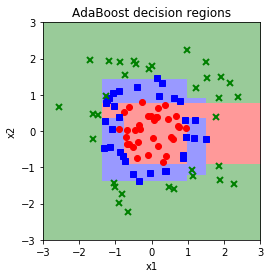

**Write a few lines of code** train the classifier and plot the resulting decision regions. Use the *plot_predict* and *plot_data* functions defined at the start of the lab. Use *random_state*=1 and *algorithm*='SAMME' as before.

In [ ]:
ada_gauss = sklearn.ensemble.AdaBoostClassifier(n_estimators=100, random_state=1)
ada_gauss.fit(X_gauss, y_gauss)
plt.figure()
draw_model_pred(ada_gauss)
draw_2d_toy_data(X_gauss, y_gauss)
plt.title('AdaBoost (n_estimators=100)')


Text(0.5, 1.0, 'AdaBoost (n_estimators=100)')

You may notice that the default AdaBoost hyperparameters struggle to fit this particular data. You can try playing with the *learning_rate* or *n_estimators* parameters to see how they effect the result.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 4.5 &mdash; Plot the decision regions of successive boosting "rounds"

You are asked to plot the decision regions of an AdaBoost classifier with *n_estimators* $\in [1, 20, 40, 60, 80, 100]$. There should be 6 plots and your first plot should look like this:



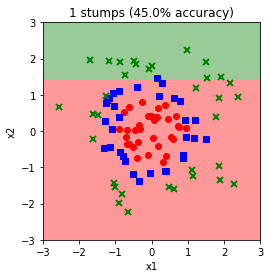

**Write a few lines of code** to generate the plots.
* Use *algorithm*='SAMME' (this is the default so you do not have to pass it explicitly) and *random_state*=1 when training, as before.
* Use a for-loop and generate a new plot on each iteration.
* In each plot, display the *accuracy_score* on the training set in the title, as shown above.

In [ ]:
for n in [1, 20, 40, 60, 80, 100]:
    ada_n = sklearn.ensemble.AdaBoostClassifier(n_estimators=n, random_state=1)
    ada_n.fit(X_gauss, y_gauss)
    acc = sklearn.metrics.accuracy_score(y_gauss, ada_n.predict(X_gauss))
    plt.figure()
    draw_model_pred(ada_n)
    draw_2d_toy_data(X_gauss, y_gauss)
    plt.title(f'AdaBoost n_estimators={n}  train_acc={acc:.3f}')


Notice that the accuracy fluctuates and is not particularly good even after 100 rounds of boosting.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 4.6 &mdash; Plot the training accuracy of successive boosting "rounds"

You are asked to plot the accuracy of an AdaBoost classifier with *n_estimators*$=1, 2, \ldots, 100$ decision stumps (estimators). This is just like Exercise 2.3 except you do not plot the decision regions, and instead keep a record of all the accuracies. Your plot should end up looking like this:



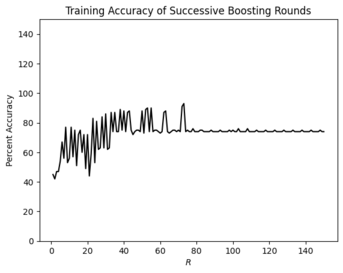

**Write a few lines of code** to generate the plot.
* Use *algorithm*='SAMME' and *random_state*=1 as before.
* Compute a list of 150 accuracies, one for each *n_estimators* setting.
* Plot the accuracies with a single call to Matplotlib's *plot* function.

In [ ]:
ada_150 = sklearn.ensemble.AdaBoostClassifier(n_estimators=150, random_state=1)
ada_150.fit(X_gauss, y_gauss)

accuracies = list(ada_150.staged_score(X_gauss, y_gauss))
print(f'Number of staged accuracies: {len(accuracies)}')

plt.figure()
plt.plot(range(1, len(accuracies) + 1), accuracies)
plt.xlabel('n_estimators')
plt.ylabel('Training accuracy')
plt.title('AdaBoost staged training accuracy (150 rounds)')


Number of staged accuracies: 150


Text(0.5, 1.0, 'AdaBoost staged training accuracy (150 rounds)')